<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/BTC_Gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Datos: 2018-01-03 → 2026-06-23  (2129 obs)
          BTC_ret    Gold_ret
count  2129.00000  2129.00000
mean      0.00067     0.00054
std       0.04072     0.01094
min      -0.46473    -0.12066
25%      -0.01677    -0.00430
50%       0.00072     0.00073
75%       0.01927     0.00611
max       0.20305     0.05905

Pearson:  0.1073
Spearman: 0.1091


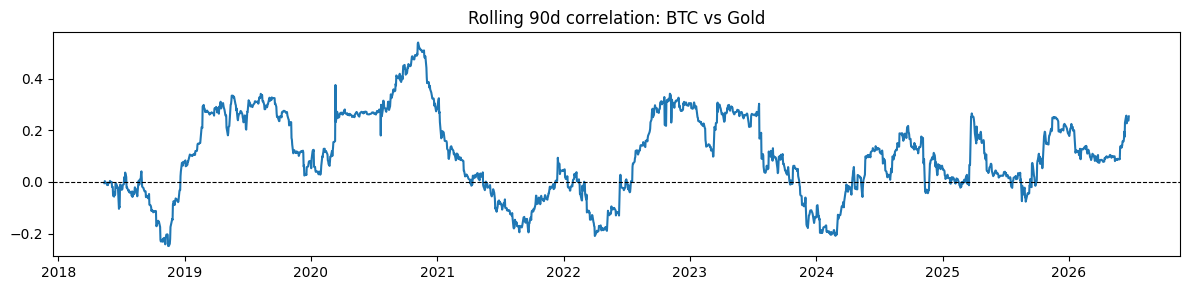

ADF BTC_ret: stat=-25.006  p=0.0000  ✓ estacionaria
ADF Gold_ret: stat=-19.535  p=0.0000  ✓ estacionaria

── ARIMA ──────────────────────────────────────────────
                               SARIMAX Results                                
Dep. Variable:                BTC_ret   No. Observations:                 2129
Model:                 ARIMA(1, 0, 1)   Log Likelihood                3797.016
Date:                Tue, 23 Jun 2026   AIC                          -7586.032
Time:                        18:51:24   BIC                          -7563.378
Sample:                             0   HQIC                         -7577.740
                               - 2129                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      0.752     

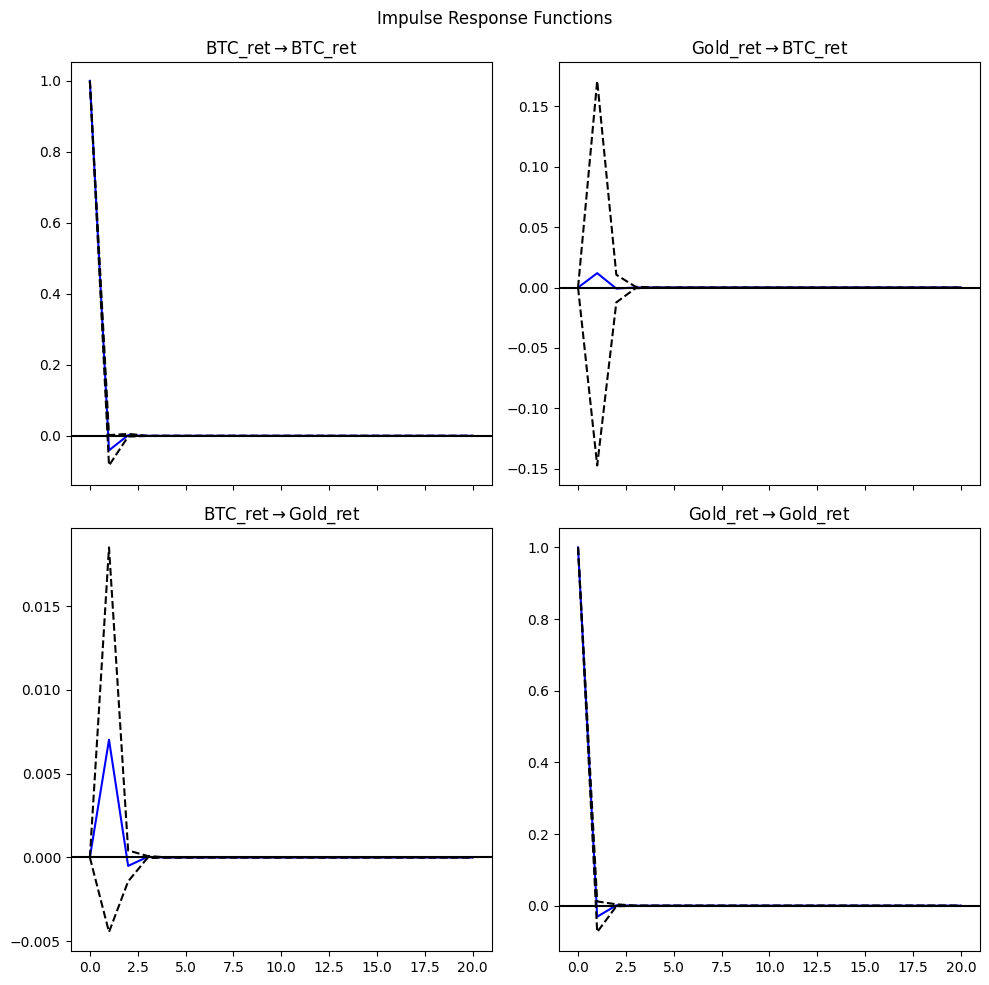


  SEÑAL HOY        : LONG
  ARIMA forecast   : +0.00218
  VAR   forecast   : +0.00173
  GARCH vol diaria : 0.0327  (umbral 0.04)

── Backtesting results (walk-forward, 252d window) ──
Sharpe anualizado  : 0.373
Max Drawdown       : -24.18%
Hit rate           : 53.7%
Días en mercado    : 147 / 1877
Coste total acumulado : 28.60%


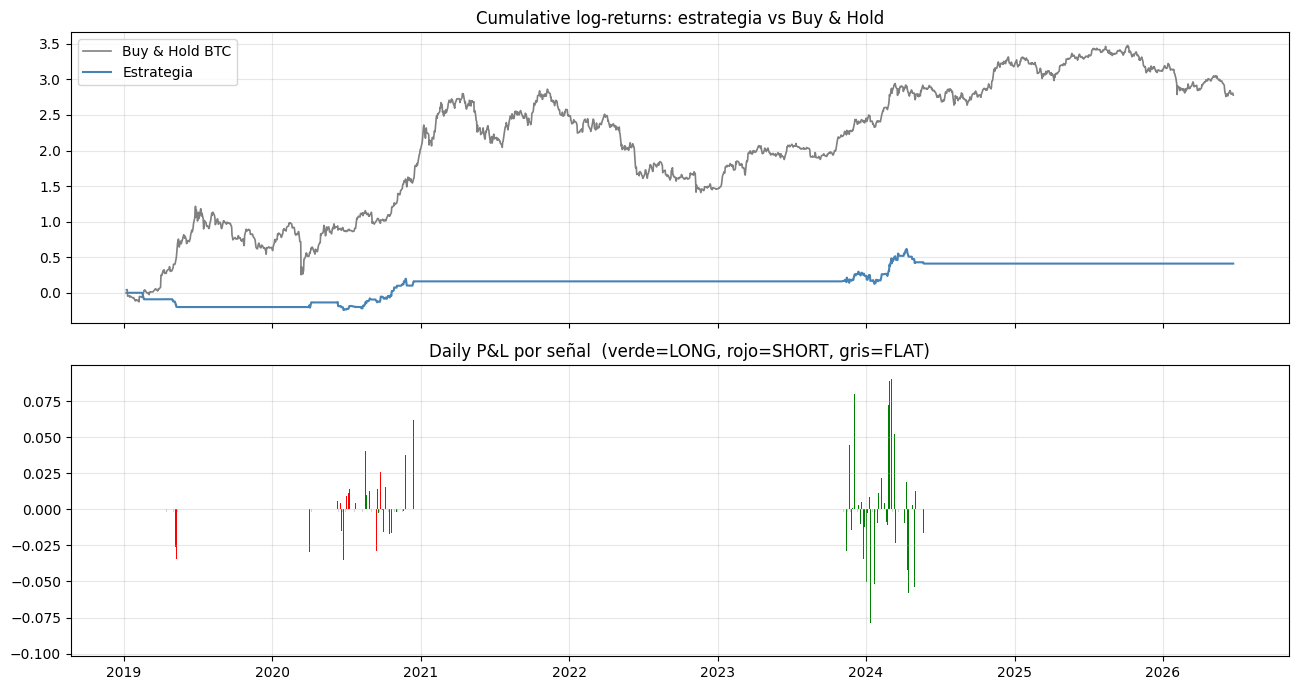

In [1]:
!pip install arch statsmodels yfinance pandas-datareader
# ═══════════════════════════════════════════════════════════════
# 1. LIBRERÍAS
# ═══════════════════════════════════════════════════════════════
import yfinance as yf
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')
START = '2018-01-01'

# ═══════════════════════════════════════════════════════════════
# 2. DATOS
# ═══════════════════════════════════════════════════════════════
btc_raw = yf.download('BTC-USD', start=START, auto_adjust=True)['Close']
btc = btc_raw.squeeze()
btc.index = pd.to_datetime(btc.index).tz_localize(None)
btc.name = 'BTC'

gold_raw = yf.download('GC=F', start=START, auto_adjust=True)['Close']
gold = gold_raw.squeeze()
gold.index = pd.to_datetime(gold.index).tz_localize(None)
gold.name = 'Gold'

df = pd.concat([btc, gold], axis=1).dropna()
df.columns = ['BTC', 'Gold']

df['BTC_ret']  = np.log(df['BTC']  / df['BTC'].shift(1))
df['Gold_ret'] = np.log(df['Gold'] / df['Gold'].shift(1))
df.dropna(inplace=True)

print(f"Datos: {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} obs)")
print(df[['BTC_ret', 'Gold_ret']].describe().round(5))

# ═══════════════════════════════════════════════════════════════
# 3. ANÁLISIS EXPLORATORIO
# ═══════════════════════════════════════════════════════════════

# -- Correlación estática --
print(f"\nPearson:  {df['BTC_ret'].corr(df['Gold_ret']):.4f}")
print(f"Spearman: {df['BTC_ret'].corr(df['Gold_ret'], method='spearman'):.4f}")

# -- Correlación rolling 90 días --
rolling_corr = df['BTC_ret'].rolling(90).corr(df['Gold_ret'])
plt.figure(figsize=(12, 3))
plt.plot(rolling_corr)
plt.axhline(0, color='black', lw=0.8, ls='--')
plt.title('Rolling 90d correlation: BTC vs Gold')
plt.tight_layout(); plt.show()

# -- Test ADF (estacionariedad) --
for col in ['BTC_ret', 'Gold_ret']:
    adf_stat, p_val, *_ = adfuller(df[col].dropna())
    print(f"ADF {col}: stat={adf_stat:.3f}  p={p_val:.4f}  {'✓ estacionaria' if p_val < 0.05 else '✗ no estacionaria'}")


# ═══════════════════════════════════════════════════════════════
# 4. MODELO 1 — ARIMA
# ═══════════════════════════════════════════════════════════════
print("\n── ARIMA ──────────────────────────────────────────────")

model_arima   = ARIMA(df['BTC_ret'], order=(1, 0, 1)).fit()
fc_arima      = model_arima.get_forecast(steps=1)
mu_arima      = fc_arima.predicted_mean.iloc[0]
ci_arima      = fc_arima.conf_int(alpha=0.05)

print(model_arima.summary())
print(f"\nForecast return h=1 : {mu_arima:+.5f}")
print(f"IC 95%              : [{ci_arima.iloc[0,0]:+.5f}, {ci_arima.iloc[0,1]:+.5f}]")


# ═══════════════════════════════════════════════════════════════
# 5. MODELO 2 — GARCH
# ═══════════════════════════════════════════════════════════════
print("\n── GARCH ──────────────────────────────────────────────")

btc_ret_scaled = df['BTC_ret'] * 100   # GARCH prefiere escala ~1-5

model_garch   = arch_model(btc_ret_scaled.dropna(), vol='Garch', p=1, q=1).fit(disp='off')
fc_garch      = model_garch.forecast(horizon=1, reindex=False)
var_h1        = fc_garch.variance.iloc[-1, 0]
sigma_daily   = np.sqrt(var_h1) / 100        # de vuelta a escala original
sigma_annual  = sigma_daily * np.sqrt(252)

print(model_garch.summary())
print(f"\nVarianza h=1     : {var_h1:.4f}")
print(f"Vol diaria       : {sigma_daily:.4f}  ({sigma_daily*100:.2f}%)")
print(f"Vol anualizada   : {sigma_annual:.4f}  ({sigma_annual*100:.2f}%)")


# ═══════════════════════════════════════════════════════════════
# 6. MODELO 3 — ARX
# ═══════════════════════════════════════════════════════════════
print("\n── ARX ────────────────────────────────────────────────")

model_arx  = ARIMA(df['BTC_ret'], exog=df['Gold_ret'], order=(1, 0, 0)).fit()

# Para forecast: supuesto random walk sobre Gold (último valor conocido)
last_gold  = df['Gold_ret'].iloc[-1]
future_x   = np.array([[last_gold]])
fc_arx     = model_arx.get_forecast(steps=1, exog=future_x)
mu_arx     = fc_arx.predicted_mean.iloc[0]

print(model_arx.summary())
print(f"\nForecast return h=1 (Gold=rw): {mu_arx:+.5f}")


# ═══════════════════════════════════════════════════════════════
# 7. MODELO 4 — VAR
# ═══════════════════════════════════════════════════════════════
print("\n── VAR ────────────────────────────────────────────────")

data_var      = df[['BTC_ret', 'Gold_ret']]
model_var_fit = VAR(data_var)

# Selección de orden por AIC
lag_sel = model_var_fit.select_order(maxlags=10)
print(lag_sel.summary())
p_opt = lag_sel.aic

results_var = model_var_fit.fit(p_opt)
print(results_var.summary())

# Forecast h=1
if p_opt == 0:
    print("AIC seleccionó lag=0 — usando lag=1 por defecto")
    p_opt = 1
    results_var = VAR(data_var).fit(p_opt)

fc_var       = results_var.forecast(data_var.values[-p_opt:], steps=1)
mu_var_btc   = fc_var[0][0]
mu_var_gold  = fc_var[0][1]

print(f"\nVAR forecast BTC  h=1 : {mu_var_btc:+.5f}")
print(f"VAR forecast Gold h=1 : {mu_var_gold:+.5f}")

# Granger causality
print("\n-- Granger: ¿Gold → BTC? --")
print(results_var.test_causality('BTC_ret', 'Gold_ret', kind='f').summary())

# IRF
irf = results_var.irf(periods=20)
irf.plot(orth=False)
plt.suptitle('Impulse Response Functions')
plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════
# 8. SEÑAL DE TRADING (generación en t=hoy)
# ═══════════════════════════════════════════════════════════════
VOL_THRESHOLD = 0.04   # ~4% vol diaria → FLAT

arima_dir = np.sign(mu_arima)
var_dir   = np.sign(mu_var_btc)

if sigma_daily > VOL_THRESHOLD:
    signal = 'FLAT'
elif arima_dir == var_dir == 1:
    signal = 'LONG'
elif arima_dir == var_dir == -1:
    signal = 'SHORT'
else:
    signal = 'FLAT'

print(f"\n{'='*45}")
print(f"  SEÑAL HOY        : {signal}")
print(f"  ARIMA forecast   : {mu_arima:+.5f}")
print(f"  VAR   forecast   : {mu_var_btc:+.5f}")
print(f"  GARCH vol diaria : {sigma_daily:.4f}  (umbral {VOL_THRESHOLD})")
print(f"{'='*45}")


# ═══════════════════════════════════════════════════════════════
# 9. BACKTESTING — walk-forward out-of-sample
# ═══════════════════════════════════════════════════════════════
TRAIN_WINDOW  = 252   # días de historia para cada refit
VOL_THRESHOLD = 0.04
COST_PER_TRADE = 0.002  # 0.2% por operación (ida o vuelta)

results_bt = []

for i in range(TRAIN_WINDOW, len(df)):
    window = df.iloc[i - TRAIN_WINDOW : i]
    today  = df.iloc[i]

    try:
        # ARIMA
        ar = ARIMA(window['BTC_ret'], order=(1, 0, 1)).fit()
        mu_ar = ar.forecast(steps=1).iloc[0]
    except:
        mu_ar = 0

    try:
        # GARCH
        ga = arch_model(window['BTC_ret'] * 100, vol='Garch', p=1, q=1).fit(disp='off')
        v  = ga.forecast(horizon=1, reindex=False).variance.iloc[-1, 0]
        sig = np.sqrt(v) / 100
    except:
        sig = VOL_THRESHOLD + 1

    # VAR
    try:
        va = VAR(window[['BTC_ret', 'Gold_ret']]).fit(maxlags=5, ic='aic')
        if va.k_ar == 0:
            mu_var = 0
        else:
            fc_v   = va.forecast(window[['BTC_ret', 'Gold_ret']].values[-va.k_ar:], steps=1)
            mu_var = fc_v[0][0]
    except:
        mu_var = 0

    # Señal
    if sig > VOL_THRESHOLD:
        sig_label = 'FLAT'
    elif np.sign(mu_ar) == np.sign(mu_var) == 1:
        sig_label = 'LONG'
    elif np.sign(mu_ar) == np.sign(mu_var) == -1:
        sig_label = 'SHORT'
    else:
        sig_label = 'FLAT'

    pos = {'LONG': 1, 'SHORT': -1, 'FLAT': 0}[sig_label]
    prev_pos = results_bt[-1]['position'] if results_bt else 0
    trade_occurred = (pos != prev_pos)
    cost = COST_PER_TRADE if trade_occurred else 0

    ret_strategy = pos * today['BTC_ret'] - cost

    results_bt.append({
        'date':         today.name,
        'signal':       sig_label,
        'position':     pos,
        'BTC_ret':      today['BTC_ret'],
        'strategy_ret': ret_strategy,
        'cost':         cost,
    })

bt = pd.DataFrame(results_bt).set_index('date')

# -- Métricas --
bt['cum_strategy']  = bt['strategy_ret'].cumsum()
bt['cum_bh']        = bt['BTC_ret'].cumsum()       # Buy & Hold

sharpe   = bt['strategy_ret'].mean() / bt['strategy_ret'].std() * np.sqrt(252)
max_dd   = (bt['cum_strategy'] - bt['cum_strategy'].cummax()).min()
hit_rate = (bt.loc[bt['position'] != 0, 'strategy_ret'] > 0).mean()
n_trades = (bt['position'] != 0).sum()
total_costs = bt['cost'].sum()

print(f"\n── Backtesting results ({'walk-forward, ' + str(TRAIN_WINDOW) + 'd window'}) ──")
print(f"Sharpe anualizado  : {sharpe:.3f}")
print(f"Max Drawdown       : {max_dd*100:.2f}%")
print(f"Hit rate           : {hit_rate*100:.1f}%")
print(f"Días en mercado    : {n_trades} / {len(bt)}")
print(f"Coste total acumulado : {total_costs*100:.2f}%")

# -- Plot --
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(bt['cum_bh'],       label='Buy & Hold BTC', color='gray',   lw=1.2)
axes[0].plot(bt['cum_strategy'], label='Estrategia',     color='steelblue', lw=1.5)
axes[0].set_title('Cumulative log-returns: estrategia vs Buy & Hold')
axes[0].legend(); axes[0].grid(alpha=0.3)

colors = bt['signal'].map({'LONG': 'green', 'SHORT': 'red', 'FLAT': 'lightgray'})
axes[1].bar(bt.index, bt['strategy_ret'], color=colors, width=1)
axes[1].set_title('Daily P&L por señal  (verde=LONG, rojo=SHORT, gris=FLAT)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()